
# Stream Macroinvertebrates Image Classification Using MobileNet, EfficientNet  and Vision Transformer Models
# ==================================
### This notebook demonstrates how to:
### 1. Load your dataset organized by class folders (without predefined splits)
### 2. Perform train/validation split in code
### 3. Augment data during training
### 4. Build transfer learning model with **MobileNet**,  **EfficientNet** and **Vision Transformer Model** pretrained on ImageNet
### 5. Train, evaluate, and predict on new images


In [69]:
%cd /content/drive/MyDrive/2026_Teaching/ST1/Week_7_Tut_Lab_Activities

/content/drive/MyDrive/2026_Teaching/ST1/Week_7_Tut_Lab_Activities



## Step 0: Data Preparation
  
1.   Set the run time to one of the GPU options by selecting Runtime/Change Runtime type/...

2. Set the working folder for google colab notebook to the folder in the google drive.

3. Download stream invertebrates dataset from Kaggle (https://www.kaggle.com/datasets/kennethtm/stream-macroinvertebrates/data ) and unzip it in google drive folder. You will find stream macroinvertebrates dataset in the unzipped archive folder ( You can do this outside colab as well).

4. Manually create a insects_dataset folder in Assets folder.

5. The images for each insect species in a separate folder, with folder name as the species name.

6. Pick any three insect species from the unzipped archive folder. The three species you select need to be other than the three species shown in this demo.

6. Create two new folders train_data and test_data in insects_dataset folder you just created in Step 4.

7. Move five images from each species you have selected into the test_data folder. Please note that they need to be moved, not copied. In total you would have 15 images in the test_data folder (5 images corresponding to each species).

8. Move remaining folders into train_data folder. Please note that you will not move each image, but move each folder containing remaining images into the train_data folder. After moving you will see three folders in train_data folder, with each folder containing several insect images corresponding to each insect species.



In [70]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [71]:
import os
print(os.listdir('/content/drive/MyDrive'))

['Ff.gdoc', 'Wed wedding ', 'Navajo People.gslides', 'Emma Copy.gform', 'نموذج بدون عنوان.gform', 'Untitled Diagram.drawio', 'Saved from the Google app', 'Database design.gdoc', '9b57fdad-ad10-46a9-9ed0-9922fc08b418.mp4', 'Colab Notebooks', 'insects_dataset', 'ST1_Week_7_Tut_Lab_(2)_(1).ipynb', 'ST1_Week_8_Tut_Lab.pdf', 'ST1_Week_8_Tut_Lab (1).ipynb', '2026_Teaching']


In [72]:
import os
print(os.listdir('/content/drive/MyDrive/2026_Teaching'))

['ST1']


In [73]:
import os
print(os.listdir('/content/drive/MyDrive/2026_Teaching/ST1'))

['Week_7_Tut_Lab_Activities']


In [74]:
import os
print(os.listdir('/content/drive/MyDrive/2026_Teaching/ST1/Week_7_Tut_Lab_Activities'))

['Assets']


In [75]:
import os
print(os.listdir('/content/drive/MyDrive/2026_Teaching/ST1/Week_7_Tut_Lab_Activities/Assets'))

['insects_dataset']


In [76]:
import os
print(os.listdir('/content/drive/MyDrive/2026_Teaching/ST1/Week_7_Tut_Lab_Activities/Assets/insects_dataset'))

['test_data']


In [77]:
import os
print(os.listdir('/content/drive/MyDrive/insects_dataset/test_data'))

['Ant', 'Spider', 'Beetle']


In [78]:
import os
print(os.listdir(TEST_IMAGE_DIR))

['Ant', 'Spider', 'Beetle']


In [79]:
#!unzip archive.zip

**1. Mobile-Net Model**

In [80]:
#Step 1
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image

# === USER VARIABLES ===

# Path to your dataset folder organized by class subfolders
#DATASET_DIR = 'dataset/'  # Change to your dataset path
DATASET_DIR = '/content/drive/MyDrive/insects_dataset/train_data'
# Image input size and batch size for training
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 123  # For deterministic shuffling/splitting

# === STEP 1: Load dataset and split into train/validation ===

print("Loading dataset with 80/20 train-validation split...")
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Classes found: {class_names}")




Loading dataset with 80/20 train-validation split...
Found 26 files belonging to 3 classes.
Using 21 files for training.
Found 26 files belonging to 3 classes.
Using 5 files for validation.
Classes found: ['Ant', 'Beetle', 'Spider']


In [81]:
# === STEP 2: Optimize dataset performance ===

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

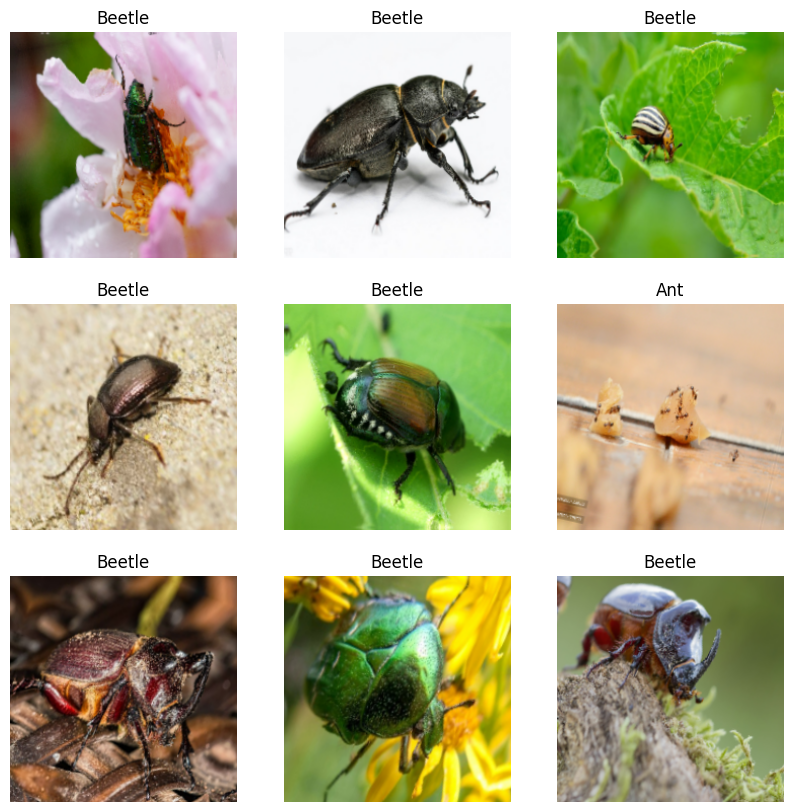

In [82]:
# === STEP 3: Data augmentation (recommended) ===

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Visualize some augmented images
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    augmented_images = data_augmentation(images)
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

In [83]:
# === STEP 4: Build transfer learning model ===

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False  # Freeze the base model initially

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_3 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_2 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_2 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [84]:

# === STEP 5: Train the model ===

EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - accuracy: 0.3333 - loss: 1.6521 - val_accuracy: 0.4000 - val_loss: 1.0267
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 0.1905 - loss: 1.4036 - val_accuracy: 0.6000 - val_loss: 0.8669
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 0.4286 - loss: 1.1747 - val_accuracy: 0.6000 - val_loss: 0.7710
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.4762 - loss: 1.0413 - val_accuracy: 0.8000 - val_loss: 0.7113
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 0.7143 - loss: 0.8600 - val_accuracy: 0.8000 - val_loss: 0.6734
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 592ms/step - accuracy: 0.7143 - loss: 0.8142 - val_accuracy: 0.8000 - val_loss: 0.6454
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 0.6667 - loss: 0.7120 - val_accuracy: 0.8000 - val_loss: 0.6237
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.7619 - loss: 0.6550 - val_accuracy: 0.8000 - val_loss: 0.

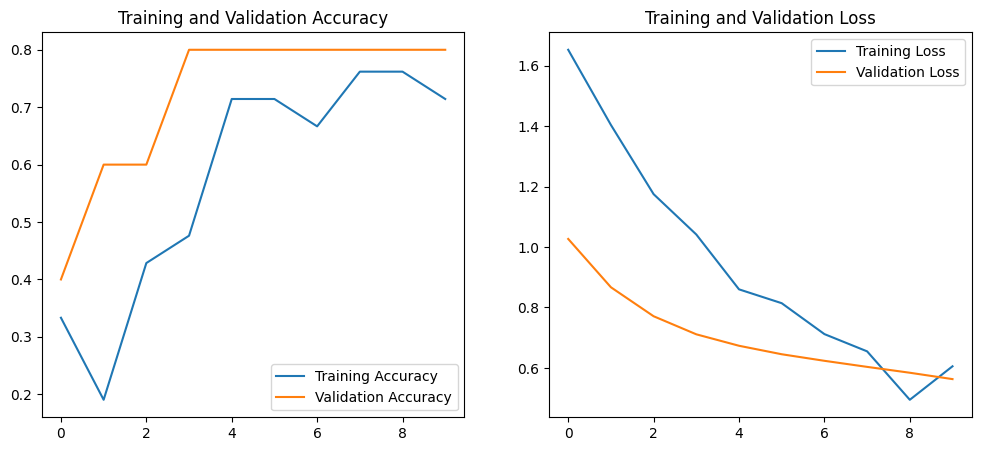

In [85]:
# === STEP 6: Plot training curves ===

# Re-extracting from history to ensure correct length for initial EPOCHS
initial_acc = history.history['accuracy']
initial_val_acc = history.history['val_accuracy']
initial_loss = history.history['loss']
initial_val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, initial_acc, label='Training Accuracy')
plt.plot(epochs_range, initial_val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, initial_loss, label='Training Loss')
plt.plot(epochs_range, initial_val_loss, label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [86]:
# === STEP 7: Evaluate on validation set ===

val_loss, val_acc = model.evaluate(val_ds)
print(f'Validation accuracy: {val_acc*100:.2f}%')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.8000 - loss: 0.5632
Validation accuracy: 80.00%


In [87]:
# === STEP 9: Save the trained model ===
%cd /content/drive/MyDrive/2026_Teaching/ST1/Week_7_Tut_Lab_Activities
model.save('macroinvertebrates_classifier.h5')
print("Model saved as 'macroinvertebrates_classifier.h5'")

/content/drive/MyDrive/2026_Teaching/ST1/Week_7_Tut_Lab_Activities
Model saved as 'macroinvertebrates_classifier.h5'


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


<Figure size 1200x1200 with 0 Axes>

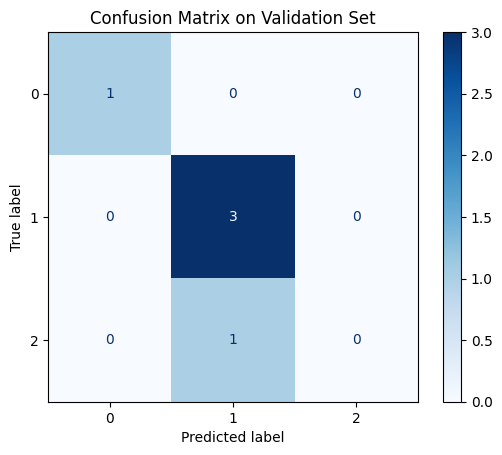

Weighted Precision: 0.6500
Weighted Recall:    0.8000
Weighted F1-score:  0.7143


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


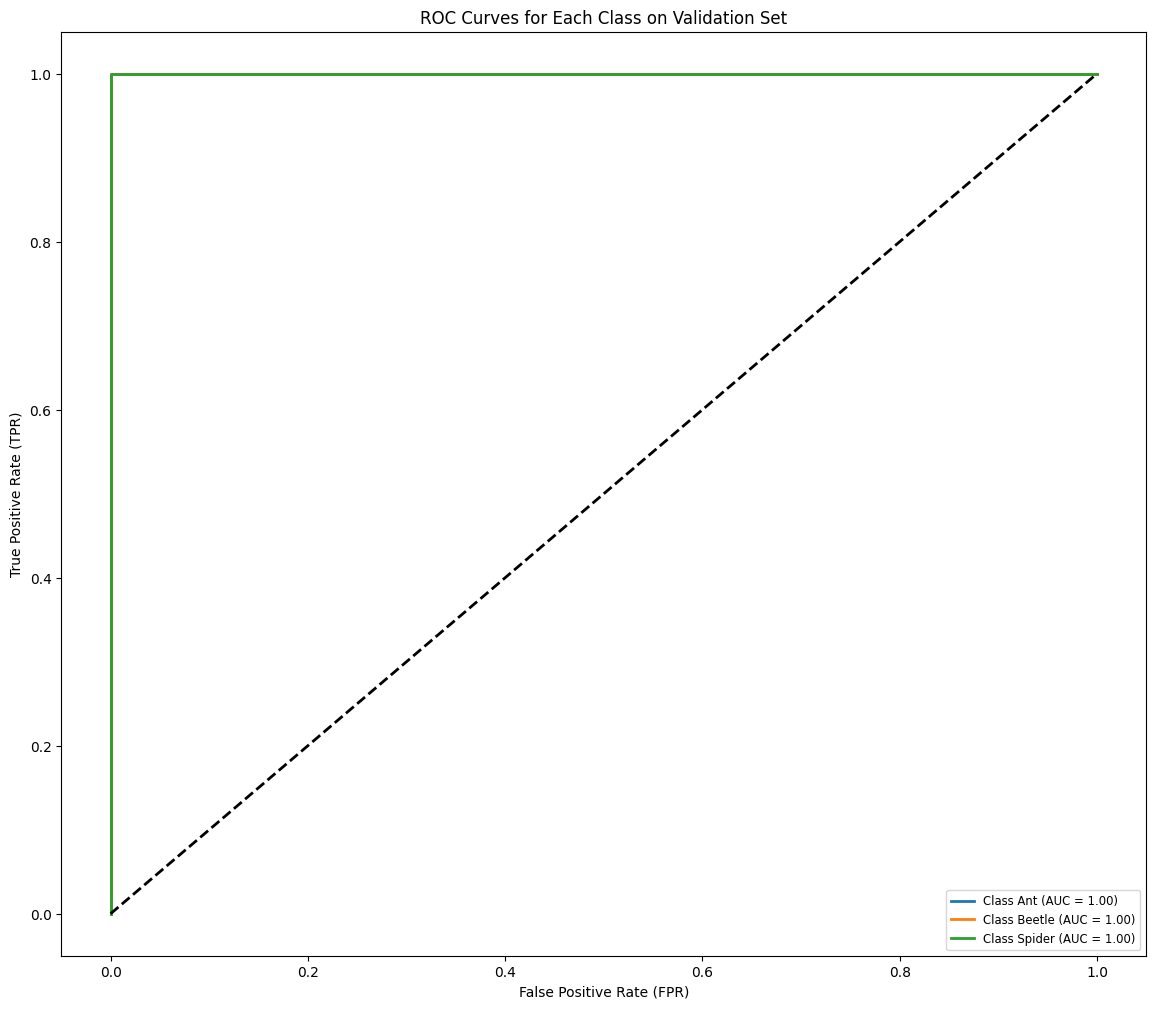

In [88]:
# === STEP 10: Evaluate model with confusion matrix, precision, recall, F1-score ===

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_fscore_support,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize
import tensorflow as tf
import os

# Step 10.1: Aggregate predictions and true labels from validation dataset
y_true = []
y_pred = []
y_scores = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
    y_scores.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_scores = np.array(y_scores)

# Step 10.2: Confusion Matrix Plot
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure(figsize=(12,12))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix on Validation Set')
plt.show()

# Step 10.3: Precision, Recall, F1-score (weighted average)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted'
)
print(f"Weighted Precision: {precision:.4f}")
print(f"Weighted Recall:    {recall:.4f}")
print(f"Weighted F1-score:  {f1:.4f}")

# Step 10.4: Multi-class ROC curves and AUC

# Binarize the labels for multi-class ROC
y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
n_classes = y_true_bin.shape[1]

fpr = dict()
tpr = dict()
roc_auc = dict()

plt.figure(figsize=(14, 12))

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], lw=2,
             label=f'Class {class_names[i]} (AUC = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curves for Each Class on Validation Set")
plt.legend(loc="lower right", fontsize='small')
plt.show()



In [89]:
# === STEP 12: Inference on new images in 'test_images' folder ===

#TEST_IMAGE_DIR = 'test_images'
TEST_IMAGE_DIR = '/content/drive/MyDrive/2026_Teaching/ST1/Week_7_Tut_Lab_Activities/Assets/insects_dataset/test_data'
os.makedirs(TEST_IMAGE_DIR, exist_ok=True)

def load_and_preprocess_image(img_path, img_size=IMG_SIZE):
    img = image.load_img(img_path, target_size=img_size)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)  # batch size 1
    return img_array

def predict_new_images(test_dir):
    img_files = [f for f in os.listdir(test_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if not img_files:
        print(f"No images found in '{test_dir}'. Please add some images and rerun.")
        return

    for img_file in img_files:
        path = os.path.join(test_dir, img_file)
        img_arr = load_and_preprocess_image(path)
        preds = model.predict(img_arr)
        pred_idx = np.argmax(preds[0])
        confidence = preds[0][pred_idx]

        print(f"Original Image: {img_file} --> Predicted: {class_names[pred_idx]} ({confidence*100:.2f}%)")
        img = image.load_img(path)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Prediction: {class_names[pred_idx]} ({confidence*100:.2f}%)")
        plt.show()

print("Running inference on images from 'test_images' folder...")
predict_new_images(TEST_IMAGE_DIR)


Running inference on images from 'test_images' folder...
No images found in '/content/drive/MyDrive/2026_Teaching/ST1/Week_7_Tut_Lab_Activities/Assets/insects_dataset/test_data'. Please add some images and rerun.


**2. EfficientNet Model**

In [90]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import os


In [91]:
DATASET_DIR = '/content/drive/MyDrive/insects_dataset/train_data'

In [92]:
IMG_SIZE = (224, 224)        # EfficientNetB0 default input size
BATCH_SIZE = 32
SEED = 123

In [93]:
# === STEP 1: Load dataset with 80/20 train-validation split ===

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)

Found 26 files belonging to 3 classes.
Using 21 files for training.
Found 26 files belonging to 3 classes.
Using 5 files for validation.
Classes: ['Ant', 'Beetle', 'Spider']


In [94]:
# === STEP 2: Optimize dataset performance ===

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

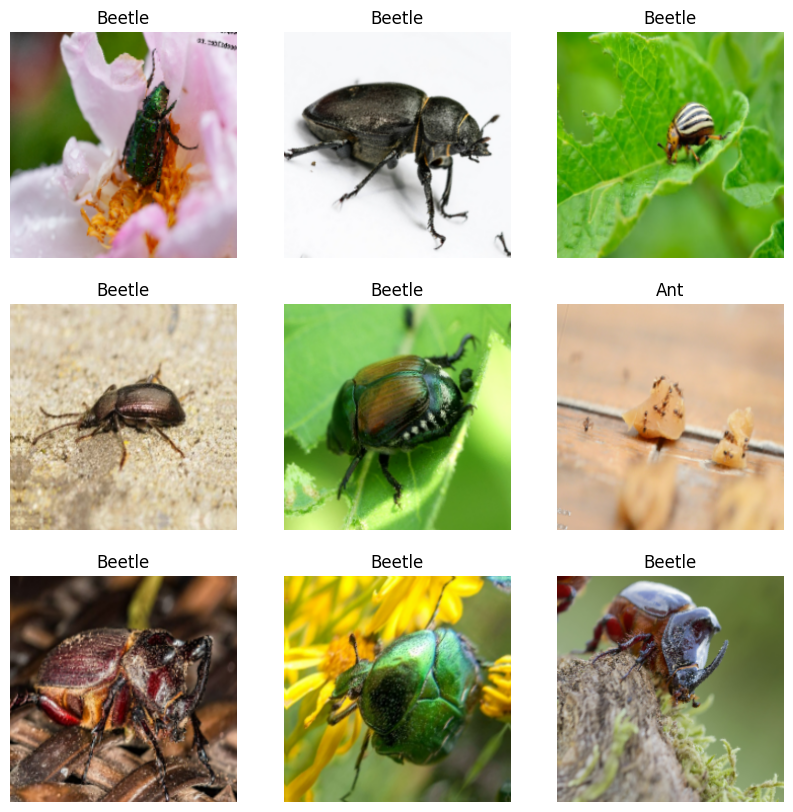

In [95]:
# === STEP 3: Data augmentation ===

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Optional: visualize augmented images
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    augmented = data_augmentation(images)
    for i in range(9):
        ax = plt.subplot(3, 3, i+1)
        plt.imshow(augmented[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()


In [96]:
# === STEP 4: Build transfer learning model with EfficientNetB0 ===

base_model = tf.keras.applications.EfficientNetB0(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # freeze base

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)               # apply augmentation
x = tf.keras.applications.efficientnet.preprocess_input(x)  # preprocess as EfficientNet expects
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)
model = models.Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,053,414 (15.46 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [97]:
# === STEP 5: Train the model ===

EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step - accuracy: 0.0476 - loss: 1.4188 - val_accuracy: 0.4000 - val_loss: 1.2967
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step - accuracy: 0.3810 - loss: 1.1779 - val_accuracy: 0.4000 - val_loss: 1.1800
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.2381 - loss: 1.0813 - val_accuracy: 0.4000 - val_loss: 1.0757
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 968ms/step - accuracy: 0.4762 - loss: 0.9592 - val_accuracy: 0.4000 - val_loss: 0.9842
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.7619 - loss: 0.8312 - val_accuracy: 0.8000 - val_loss: 0.9050
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 958ms/step - accuracy: 0.6667 - loss: 0.8307 - val_accuracy: 0.8000 - val_loss: 0.8365
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 662ms/step - accuracy: 0.7143 - loss: 0.7504 - val_accuracy: 0.8000 - val_loss: 0.7768
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - accuracy: 0.8571 - loss: 0.5606 - val_accuracy: 0.8000 - val_loss: 0.7245

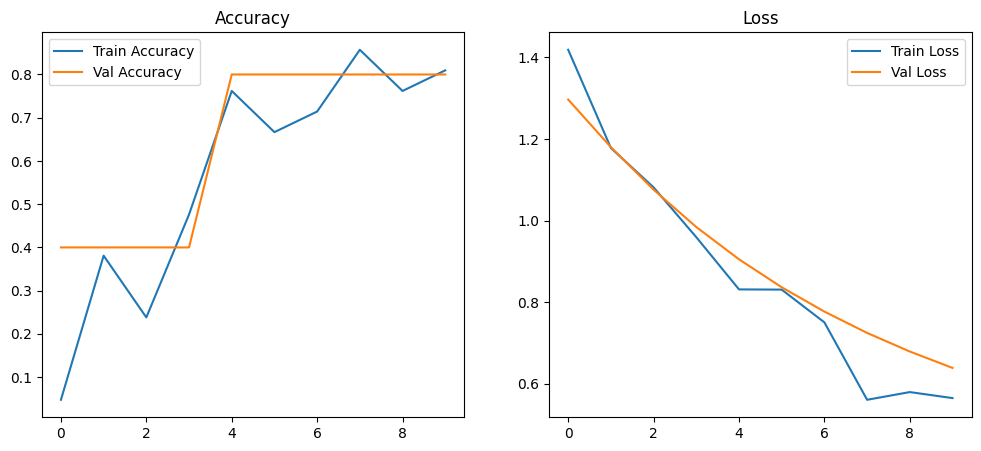

In [98]:
# === STEP 6: Plot training curves ===

acc, val_acc = history.history['accuracy'], history.history['val_accuracy']
loss, val_loss = history.history['loss'], history.history['val_loss']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.legend()
plt.title('Loss')

plt.show()

Epoch 10/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 30s 30s/step - accuracy: 0.5238 - loss: 1.0576 - val_accuracy: 0.8000 - val_loss: 0.6339
Epoch 11/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.5714 - loss: 0.9721 - val_accuracy: 0.8000 - val_loss: 0.6297
Epoch 12/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - accuracy: 0.5714 - loss: 0.9470 - val_accuracy: 0.8000 - val_loss: 0.6251
Epoch 13/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.4762 - loss: 1.0342 - val_accuracy: 0.8000 - val_loss: 0.6203
Epoch 14/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 0.5238 - loss: 0.9569 - val_accuracy: 0.8000 - val_loss: 0.6160
Epoch 15/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.5238 - loss: 0.9245 - val_accuracy: 0.8000 - val_loss: 0.6116
Epoch 16/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 617ms/step - accuracy: 0.6190 - loss: 1.0050 - val_accuracy: 0.8000 - val_loss: 0.6078
Epoch 17/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 647ms/step - accuracy: 0.5238 - loss: 0.8718 - val_accuracy: 0.8000 - va

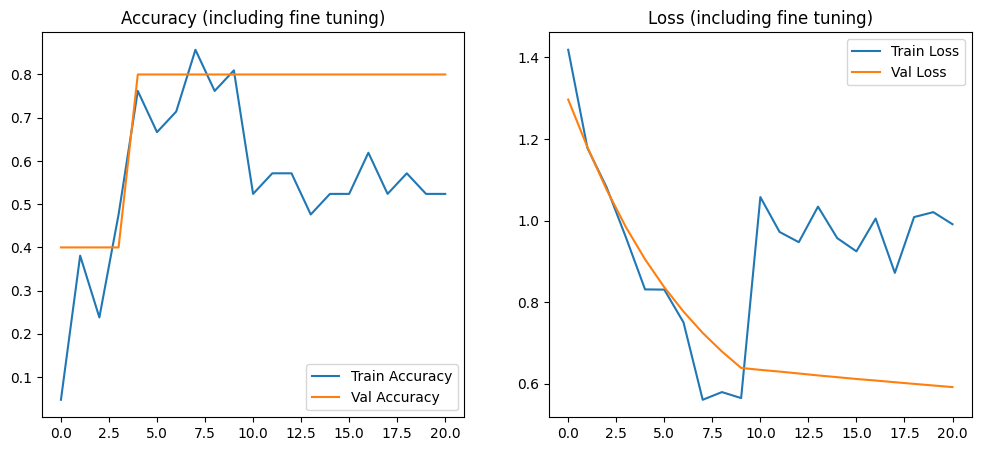

In [99]:
# === STEP 7 (Optional): Fine-tune base model ===

base_model.trainable = True

# Freeze initial layers, train last layers of EfficientNet
fine_tune_at = 100  # Freeze all layers before this
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

fine_tune_epochs = 10
total_epochs = EPOCHS + fine_tune_epochs

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=total_epochs,
    initial_epoch=history.epoch[-1]
)

# Plot fine-tuning results (optional)
acc += history_fine.history['accuracy']
val_acc += history_fine.history['val_accuracy']
loss += history_fine.history['loss']
val_loss += history_fine.history['val_loss']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.legend()
plt.title('Accuracy (including fine tuning)')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.legend()
plt.title('Loss (including fine tuning)')

plt.show()

In [100]:
import os
print(os.listdir(TEST_IMAGE_DIR))

[]


Using image: /content/drive/MyDrive/insects_dataset/test_data/Ant/Ant_22.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


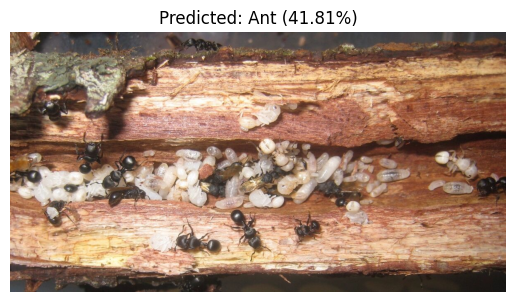

In [101]:
# === STEP 8: Prediction on new images ===

from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

def load_and_preprocess_image(img_path):
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)
    return img_array

def predict_image(img_path, model, class_names):
    img_array = load_and_preprocess_image(img_path)
    preds = model.predict(img_array)
    pred_idx = np.argmax(preds[0])
    confidence = preds[0][pred_idx]
    return class_names[pred_idx], confidence

# Example usage:


TEST_IMAGE_DIR = '/content/drive/MyDrive/insects_dataset/test_data'

# ندخل أول فولدر (مثلاً Ant)
class_folder = os.listdir(TEST_IMAGE_DIR)[0]

# ندخل داخله ونجيب أول صورة
img_name = os.listdir(os.path.join(TEST_IMAGE_DIR, class_folder))[0]

# المسار الكامل
test_img_path = os.path.join(TEST_IMAGE_DIR, class_folder, img_name)

print("Using image:", test_img_path)
predicted_class, confidence = predict_image(test_img_path, model, class_names)

plt.imshow(image.load_img(test_img_path))
plt.title(f'Predicted: {predicted_class} ({confidence*100:.2f}%)')
plt.axis('off')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
y_true shape: (5,)
y_pred shape: (5,)
Classes: ['Ant', 'Beetle', 'Spider']


<Figure size 1000x1000 with 0 Axes>

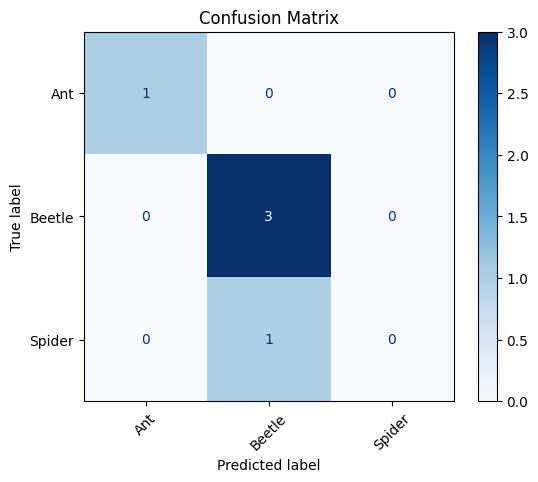

y_true shape:


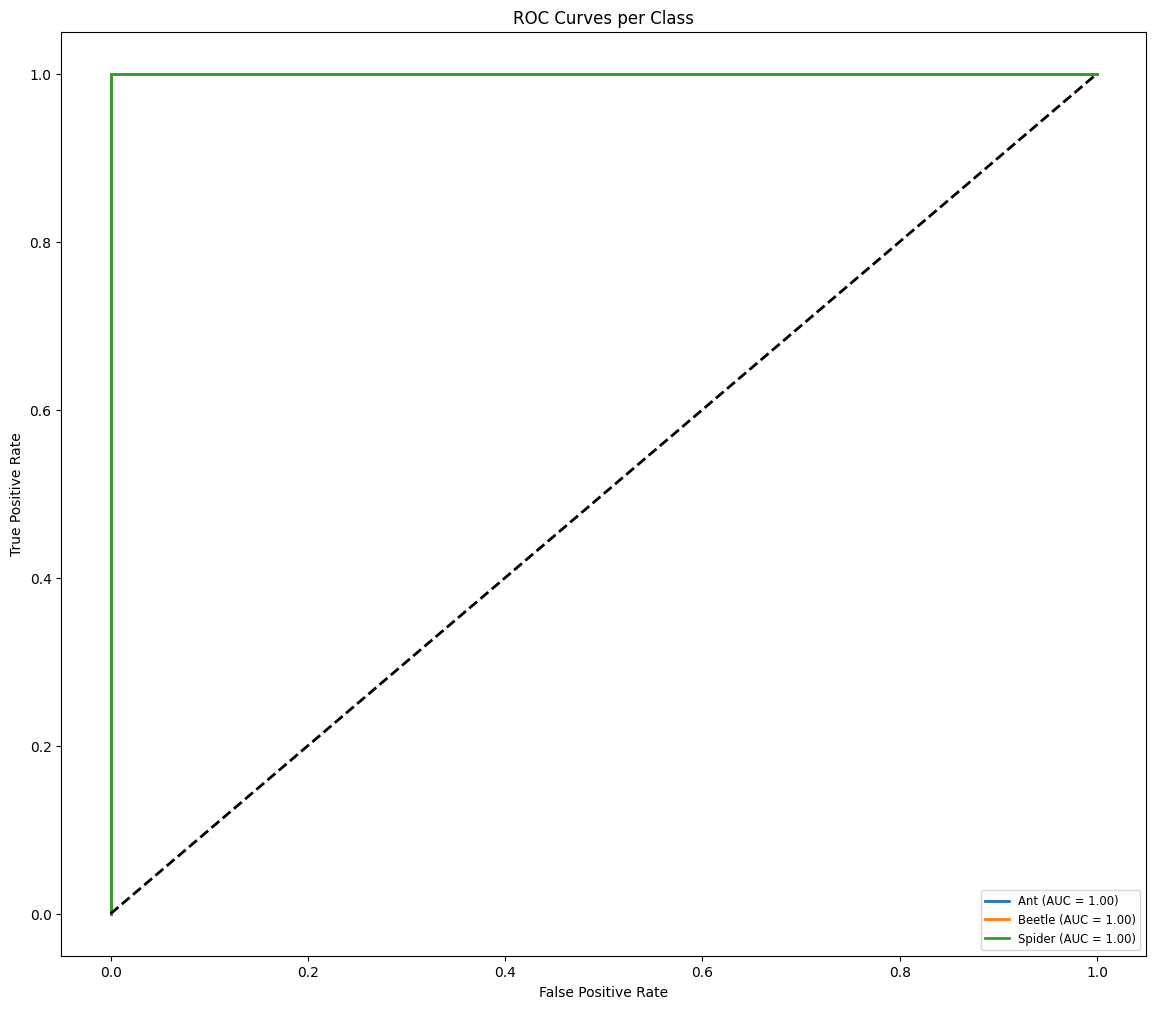

In [102]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_fscore_support,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize
import tensorflow as tf

# Aggregate true labels and predictions from validation dataset
y_true = []
y_pred = []
y_score = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
    y_score.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_score = np.array(y_score)

# Confusion Matrix
# === FIXED CONFUSION MATRIX ===

# تأكد من القيم
print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)
print("Classes:", class_names)

# حساب Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# 🔥 أهم سطر (يحل المشكلة)
labels = list(range(len(class_names)))


plt.figure(figsize=(10, 10))
disp.plot(cmap=plt.cm.Blues)

plt.xticks(ticks=labels, labels=class_names, rotation=45)
plt.yticks(ticks=labels, labels=class_names)

plt.title('Confusion Matrix')
plt.show()
print("y_true shape:")
# ROC Curve and AUC for multi-class
n_classes = len(class_names)
y_true_bin = label_binarize(y_true, classes=range(n_classes))

fpr = dict()
tpr = dict()
roc_auc = dict()

plt.figure(figsize=(14, 12))
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], lw=2, label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves per Class')
plt.legend(loc='lower right', fontsize='small')
plt.show()


In [103]:
# === STEP 12: Inference on new images in 'test_images' folder ===

#TEST_IMAGE_DIR = 'test_images'
TEST_IMAGE_DIR = '/content/drive/MyDrive/2026_Teaching/ST1/Week_7_Tut_Lab_Activities/Assets/insects_dataset/test_data'
os.makedirs(TEST_IMAGE_DIR, exist_ok=True)

def load_and_preprocess_image(img_path, img_size=IMG_SIZE):
    img = image.load_img(img_path, target_size=img_size)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)  # batch size 1
    return img_array

def predict_new_images(test_dir):
    img_files = [f for f in os.listdir(test_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if not img_files:
        print(f"No images found in '{test_dir}'. Please add some images and rerun.")
        return

    for img_file in img_files:
        path = os.path.join(test_dir, img_file)
        img_arr = load_and_preprocess_image(path)
        preds = model.predict(img_arr)
        pred_idx = np.argmax(preds[0])
        confidence = preds[0][pred_idx]

        print(f"Original Image: {img_file} --> Predicted: {class_names[pred_idx]} ({confidence*100:.2f}%)")
        img = image.load_img(path)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Prediction: {class_names[pred_idx]} ({confidence*100:.2f}%)")
        plt.show()

print("Running inference on images from 'test_images' folder...")
predict_new_images(TEST_IMAGE_DIR)


Running inference on images from 'test_images' folder...
No images found in '/content/drive/MyDrive/2026_Teaching/ST1/Week_7_Tut_Lab_Activities/Assets/insects_dataset/test_data'. Please add some images and rerun.


**3. Vision Transformer Model**

In [104]:
#!pip install tensorflow tensorflow-hub tensorflow-datasets matplotlib


In [105]:
import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
import os

In [109]:
# === User parameters ===
DATASET_DIR = '/content/drive/MyDrive/insects_dataset/train_data/'  # Your insect dataset folder organized by classes
IMG_SIZE = 224            # ViT input size
BATCH_SIZE = 32
SEED = 123
EPOCHS = 10

In [110]:

# === Step 1: Load Dataset with 80/20 split ===

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset='training',
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset='validation',
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Classes: {class_names}")

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)


Found 26 files belonging to 3 classes.
Using 21 files for training.
Found 26 files belonging to 3 classes.
Using 5 files for validation.
Classes: ['Ant', 'Beetle', 'Spider']


In [111]:
# === Step 2: Data augmentation ===

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

In [112]:
# === Step 3: Load ViT Feature Extractor from TF Hub ===

vit_url = "https://tfhub.dev/sayakpaul/vit_b16_fe/1"
vit_layer = hub.KerasLayer(vit_url, trainable=False)

In [113]:
#====Step 4:
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# Data augmentation
x = data_augmentation(inputs)

# The TF Hub ViT module expects pixel values in [0, 255].
# image_dataset_from_directory typically outputs float32 in [0, 255],
# and data_augmentation maintains this. So, no explicit [0,1] scaling is needed here.

# ViT feature extractor
# Wrap the vit_layer call in a Lambda layer to ensure proper symbolic tensor handling
features = tf.keras.layers.Lambda(lambda y: vit_layer(y))(x);

# Classification head
outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(features)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [114]:

# === Step 5: Train the model ===

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step - accuracy: 0.1905 - loss: 2.3501 - val_accuracy: 0.2000 - val_loss: 1.2924
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 527ms/step - accuracy: 0.3810 - loss: 1.3712 - val_accuracy: 0.8000 - val_loss: 1.0860
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 512ms/step - accuracy: 0.4286 - loss: 1.1379 - val_accuracy: 0.8000 - val_loss: 1.1508
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 533ms/step - accuracy: 0.5238 - loss: 1.0632 - val_accuracy: 0.6000 - val_loss: 1.2811
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 518ms/step - accuracy: 0.6190 - loss: 1.2312 - val_accuracy: 0.6000 - val_loss: 1.3895
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 511ms/step - accuracy: 0.6190 - loss: 1.2509 - val_accuracy: 0.6000 - val_loss: 1.4404
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 506ms/step - accuracy: 0.5714 - loss: 1.2875 - val_accuracy: 0.6000 - val_loss: 1.4523
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 530ms/step - accuracy: 0.5714 - loss: 1.2290 - val_accuracy: 0.6000 - val_loss: 

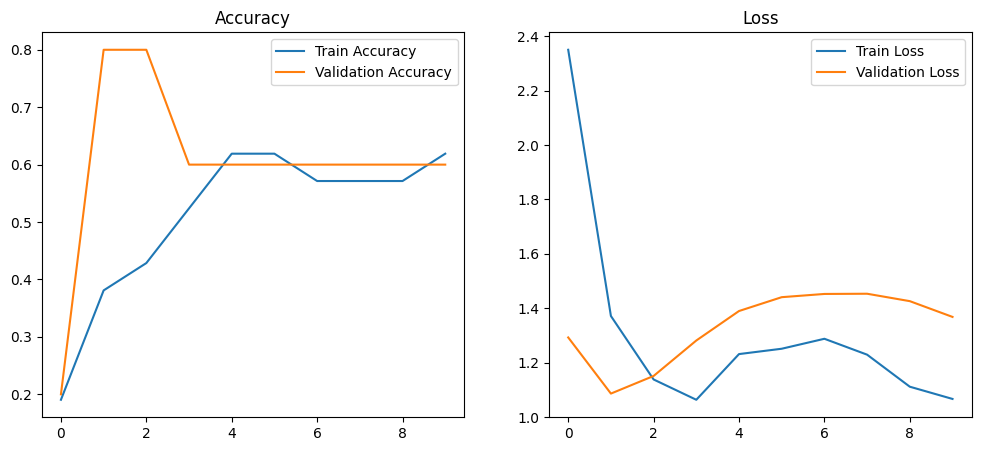

In [115]:
# === Step 6: Plot training & validation accuracy/loss ===

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.show()


In [116]:
# === Step 7: Prediction helper function ===

def load_and_preprocess_image(img_path):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0
    return img_array

def predict_image(img_path, model, class_names):
    img_array = load_and_preprocess_image(img_path)
    preds = model.predict(img_array)
    pred_idx = np.argmax(preds[0])
    confidence = preds[0][pred_idx]
    return class_names[pred_idx], confidence


Using image: /content/drive/MyDrive/insects_dataset/test_data/Ant/Ant_22.jpg


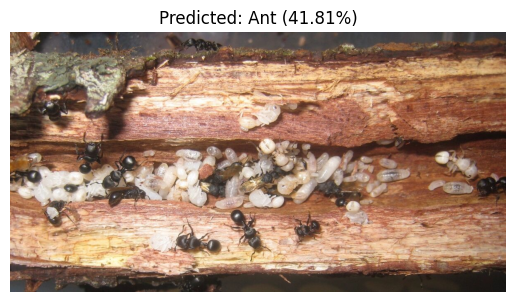

In [119]:
# === Example prediction ===
import os

TEST_IMAGE_DIR = '/content/drive/MyDrive/insects_dataset/test_data'

class_folder = os.listdir(TEST_IMAGE_DIR)[0]
img_name = os.listdir(os.path.join(TEST_IMAGE_DIR, class_folder))[0]

test_img_path = os.path.join(TEST_IMAGE_DIR, class_folder, img_name)

print("Using image:", test_img_path)

plt.imshow(tf.keras.preprocessing.image.load_img(test_img_path))
plt.title(f'Predicted: {predicted_class} ({confidence*100:.2f}%)')
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


<Figure size 1200x1200 with 0 Axes>

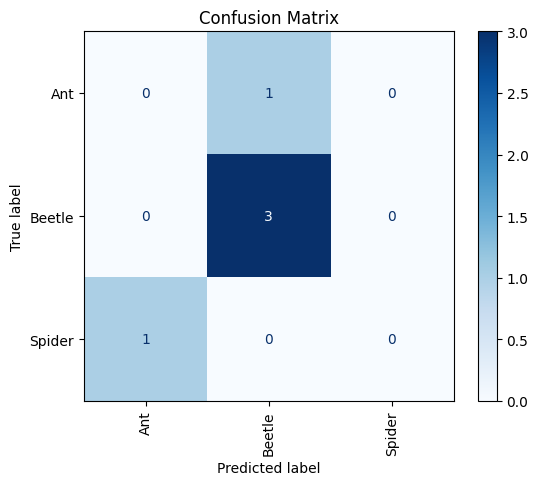

Precision: 0.4500
Recall:    0.6000
F1-score:  0.5143


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


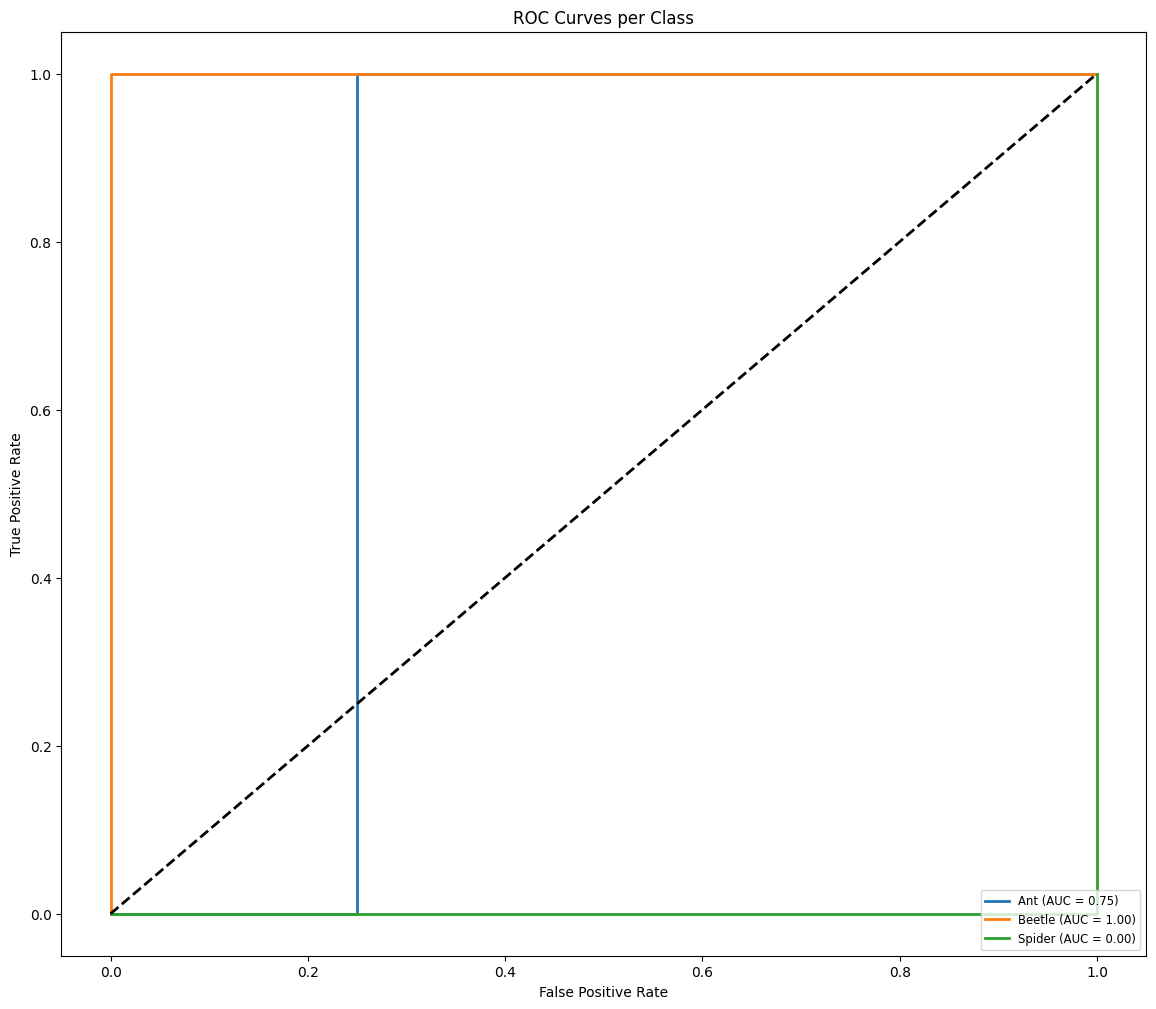

In [120]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_fscore_support,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize
import tensorflow as tf

# Aggregate true labels and predictions from validation dataset
y_true = []
y_pred = []
y_score = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
    y_score.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_score = np.array(y_score)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
plt.figure(figsize=(12, 12))
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.title('Confusion Matrix')
plt.show()

# Precision, Recall and F1-score
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted'  # options: 'micro', 'macro', None...
)
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

# ROC Curve and AUC for multi-class
n_classes = len(class_names)
y_true_bin = label_binarize(y_true, classes=range(n_classes))

fpr = dict()
tpr = dict()
roc_auc = dict()

plt.figure(figsize=(14, 12))
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], lw=2, label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves per Class')
plt.legend(loc='lower right', fontsize='small')
plt.show()


In [124]:
# === STEP 12: Inference on new images in 'test_images' folder ===

def predict_new_images(test_dir):
    for class_folder in os.listdir(test_dir):
        class_path = os.path.join(test_dir, class_folder)

        if not os.path.isdir(class_path):
            continue

        for img_file in os.listdir(class_path):
            path = os.path.join(class_path, img_file)

            img_arr = load_and_preprocess_image(path)
            preds = model.predict(img_arr)

            pred_idx = np.argmax(preds[0])
            confidence = preds[0][pred_idx]

            print(f"Image: {img_file} → Predicted: {class_names[pred_idx]} ({confidence*100:.2f}%)")

            img = image.load_img(path)
            plt.imshow(img)
            plt.axis('off')
            plt.title(f"{class_names[pred_idx]} ({confidence*100:.2f}%)")
            plt.show()

In [125]:
import os

print("Folders inside test_data:")
print(os.listdir('/content/drive/MyDrive/insects_dataset/test_data'))

Folders inside test_data:
['Ant', 'Spider', 'Beetle']


In [126]:
import os

base = '/content/drive/MyDrive/insects_dataset/test_data'

for folder in os.listdir(base):
    path = os.path.join(base, folder)
    print(folder, "→", os.listdir(path)[:5])

Ant → ['Ant_22.jpg', 'Ant_220.jpg', 'Ant_221.jpg', 'Ant_222.jpg', 'Ant_237.jpg']
Spider → ['Spider_445.jpg', 'Spider_444.jpg', 'Spider_447.jpg', 'Spider_448.jpg', 'Spider_446.jpg']
Beetle → ['Beetle_93.jpg', 'Beetle_96.jpg', 'Beetle_97.jpg', 'Beetle_98.jpg', 'Beetle_99.jpg']


In [ ]:
print("TEST")

**Evaluation Report**
* Show performance comparison of three models (MobileNet, EfficientNet, VisionTransformer Models) in terms of their performance metrics


*  Confusion Matrix screenshots,
*  precision, recall, F1-measure table
* ROC curve screenshots.
